# Task
Melakukan proyek machine learning secara menyeluruh (end-to-end) untuk memprediksi penyakit jantung menggunakan dataset processed.cleveland.data dari UCI Machine Learning Repository. Proyek ini mencakup proses pemuatan dan pemahaman dataset, penanganan nilai hilang yang direpresentasikan dengan tanda '?', serta pelaksanaan Exploratory Data Analysis (EDA) yang meliputi visualisasi distribusi target dan analisis korelasi antar fitur menggunakan heatmap.

Selanjutnya, dilakukan tahap preprocessing data dengan menerapkan one-hot encoding pada fitur kategorikal dan scaling pada fitur numerik, pembagian data menjadi data latih dan data uji, serta pembangunan dan pelatihan model klasifikasi Logistic Regression dan Random Forest.

Evaluasi kinerja model dilakukan menggunakan metrik Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix, dengan penekanan khusus pada pentingnya Recall dalam konteks medis.

Terakhir, disajikan ringkasan hasil yang diperoleh, keterbatasan model, serta saran untuk pengembangan dan penelitian lanjutan di masa depan.

## Memahami Data (Data Understanding)

### Subtask:
Muat dataset 'processed.cleveland.data' dari UCI Machine Learning Repository ke dalam DataFrame pandas. Tampilkan bentuk (shape), informasi kolom (info), dan statistik deskriptif data. Identifikasi fitur-fitur utama dan jelaskan maknanya. Tangani nilai-nilai yang hilang yang direpresentasikan dengan '?'.


In [ ]:
import pandas as pd

# Define column names as per UCI Machine Learning Repository documentation
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

print("Pandas library imported and column names defined.")

Pandas library imported and column names defined.


In [ ]:
data_url = "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(data_url, names=column_names, na_values='?')

print("Dataset loaded successfully. Displaying the first 5 rows:")
print(df.head())

print("\nShape of the DataFrame:")
print(df.shape)

print("\nInformation about the DataFrame:")
df.info()

Dataset loaded successfully. Displaying the first 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Shape of the DataFrame:
(303, 14)

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex

In [ ]:
print("\nDescriptive statistics for the DataFrame:")
print(df.describe())

print("\nNumber of missing values in each column:")
print(df.isnull().sum())


Descriptive statistics for the DataFrame:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660

In [ ]:
print("Imputing missing values in 'ca' and 'thal' with their respective modes...")
df['ca'].fillna(df['ca'].mode()[0], inplace=True)
df['thal'].fillna(df['thal'].mode()[0], inplace=True)

print("\nNumber of missing values after imputation:")
print(df.isnull().sum())

Imputing missing values in 'ca' and 'thal' with their respective modes...

Number of missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


/tmp/ipython-input-3659292386.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ca'].fillna(df['ca'].mode()[0], inplace=True)
/tmp/ipython-input-3659292386.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
print("Imputing missing values in 'ca' and 'thal' with their respective modes...")
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

print("\nNumber of missing values after imputation:")
print(df.isnull().sum())

Imputing missing values in 'ca' and 'thal' with their respective modes...

Number of missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Eksplorasi Data (EDA)

### Subtask:
Lakukan analisis data eksplorasi. Visualisasikan distribusi variabel target (penyakit jantung) dan visualisasikan korelasi antar fitur menggunakan heatmap. Sertakan interpretasi singkat dari setiap visualisasi.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries 'matplotlib.pyplot' and 'seaborn' imported successfully.")

Libraries 'matplotlib.pyplot' and 'seaborn' imported successfully.


/tmp/ipython-input-1324096444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


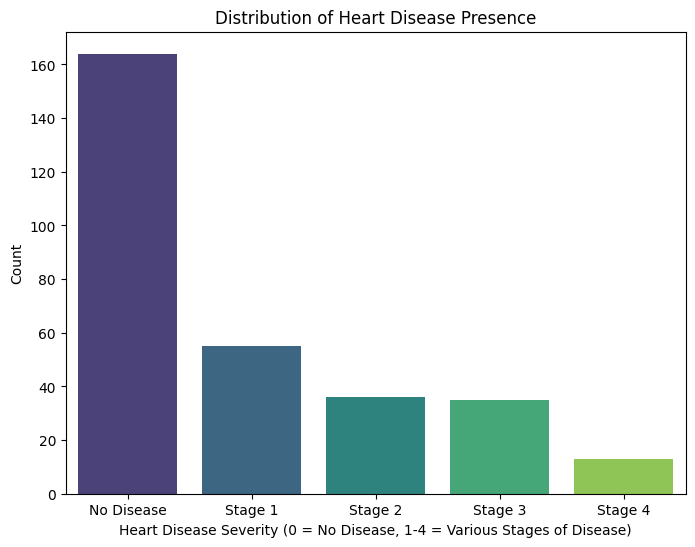

Countplot for 'target' variable displayed successfully.


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Heart Disease Presence')
plt.xlabel('Heart Disease Severity (0 = No Disease, 1-4 = Various Stages of Disease)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['No Disease', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'])
plt.show()
print("Countplot for 'target' variable displayed successfully.")

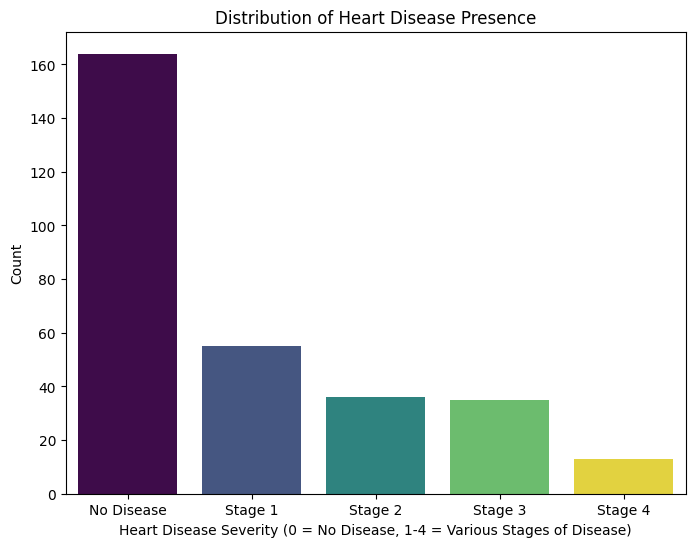

Countplot for 'target' variable displayed successfully.


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='viridis', hue='target', legend=False)
plt.title('Distribution of Heart Disease Presence')
plt.xlabel('Heart Disease Severity (0 = No Disease, 1-4 = Various Stages of Disease)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['No Disease', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'])
plt.show()
print("Countplot for 'target' variable displayed successfully.")

In [ ]:
correlation_matrix = df.corr()
print("Correlation matrix calculated successfully.")

Correlation matrix calculated successfully.


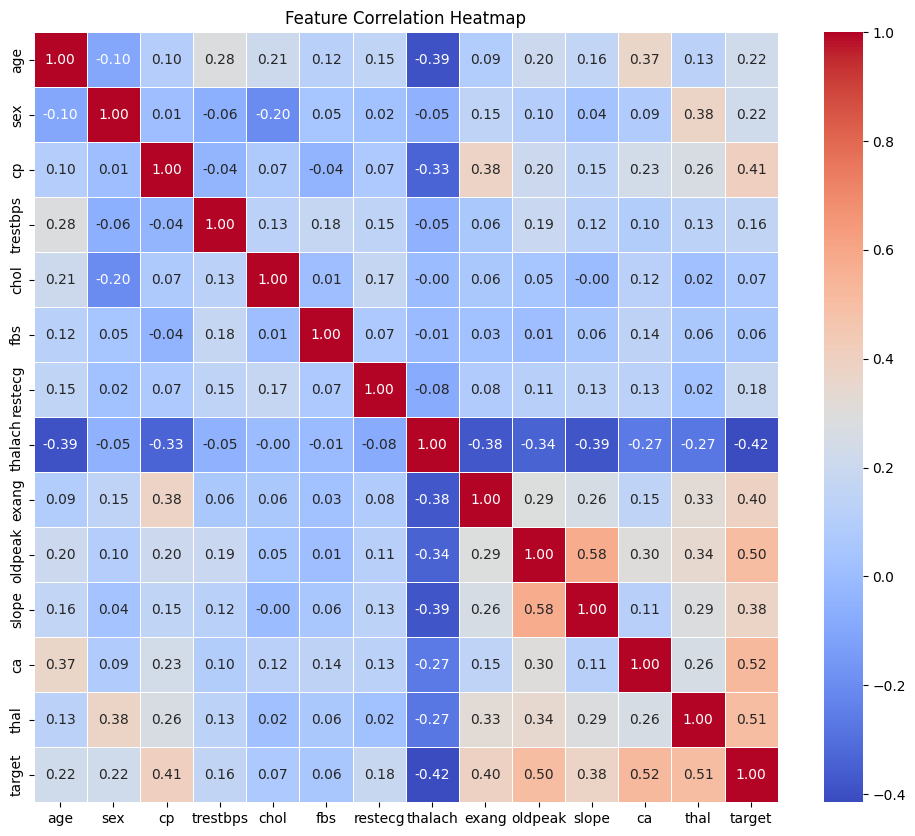

Feature correlation heatmap displayed successfully.


In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()
print("Feature correlation heatmap displayed successfully.")

Countplot menunjukkan distribusi variabel target, yang merepresentasikan keberadaan penyakit jantung (0 = tidak ada penyakit, 1–4 = berbagai tingkat keparahan penyakit).

##Interpretasi Distribusi Variabel Target:

*  **Tidak Ada Penyakit (Target = 0)**:
Kategori ini memiliki jumlah tertinggi, yang menunjukkan bahwa sebagian besar data merepresentasikan individu tanpa penyakit jantung. Ketidakseimbangan ini umum terjadi pada dataset medis, di mana populasi sehat sering kali lebih banyak dibandingkan populasi yang sakit.

*  **Tahap 1 (Target = 1)**:
Kategori ini merupakan yang terbanyak kedua, yang mengindikasikan adanya jumlah pasien yang cukup signifikan dengan penyakit jantung pada tahap awal.

*  **Tahap 2, 3, dan 4 (Target = 2, 3, 4)**:
Jumlah data pada kategori ini semakin menurun secara bertahap, dengan Tahap 4 sebagai yang paling sedikit. Hal ini menunjukkan bahwa tahap penyakit jantung yang lebih parah kurang terwakili dalam dataset dibandingkan dengan kondisi tanpa penyakit atau tahap awal.

Distribusi ini menunjukkan bahwa dataset bersifat tidak seimbang **(imbalanced)**, dengan mayoritas individu berada pada kategori tidak memiliki penyakit jantung atau hanya pada tahap awal. Ketidakseimbangan ini perlu diperhatikan dalam proses pelatihan dan evaluasi model, terutama dalam pemilihan metrik evaluasi yang tepat **(seperti Recall dan F1-Score)** dibandingkan hanya mengandalkan Accuracy.

_Heatmap_ memvisualisasikan koefisien korelasi **Pearson** antara setiap pasangan fitur dalam dataset.

### **Interpretasi Heatmap Korelasi Fitur**

#### **Korelasi dengan Variabel Target**

*   **Korelasi positif:** Fitur seperti cp (_chest pain type_), exang (_exercise induced angina_), oldpeak (_depresi segmen ST akibat aktivitas fisik dibandingkan saat istirahat_), ca (_jumlah pembuluh darah utama yang terlihat melalui fluoroskopi_), dan thal (_hasil uji stres thallium_) menunjukkan korelasi positif terhadap variabel target.Hal ini menunjukkan bahwa nilai yang lebih tinggi atau kategori tertentu dari fitur-fitur tersebut berkaitan dengan meningkatnya kemungkinan seseorang menderita penyakit jantung.
    
*   **Korelasi negatif:** Fitur thalach (_denyut jantung maksimum yang dicapai_) menunjukkan korelasi negatif dengan variabel target. Ini mengindikasikan bahwa semakin tinggi denyut jantung maksimum saat berolahraga, semakin kecil kemungkinan seseorang mengalami penyakit jantung.
    
*   Fitur sex, age, trestbps (_tekanan darah saat istirahat_), dan chol (_kadar kolesterol serum_) menunjukkan korelasi positif maupun negatif yang relatif lemah terhadap variabel target.
    

#### **Korelasi Antar Fitur**

*   Korelasi positif yang kuat antara oldpeak dan slope (_kemiringan segmen ST pada puncak aktivitas_) menunjukkan bahwa tingkat depresi segmen ST berkaitan erat dengan bentuk atau kemiringan segmen ST tersebut.
    
*   Fitur cp (_jenis nyeri dada_) dan thalach (_denyut jantung maksimum_) menunjukkan korelasi negatif yang cukup menarik, yang mengindikasikan bahwa jenis nyeri dada tertentu mungkin berhubungan dengan denyut jantung maksimum yang lebih rendah.
    
*   Fitur sex dan thalach juga menunjukkan korelasi negatif dengan tingkat sedang.
    

### **Implikasi Penting untuk Pemodelan**

*   Fitur-fitur yang memiliki korelasi tinggi dengan variabel target (seperti cp, exang, oldpeak, ca, thal, dan thalach) berpotensi menjadi prediktor yang penting dalam model prediksi penyakit jantung. Oleh karena itu, fitur-fitur ini perlu mendapatkan perhatian khusus pada tahap _feature engineering_ dan pelatihan model.
    
*   Korelasi yang kuat antar fitur independen (misalnya antara oldpeak dan slope) dapat mengindikasikan adanya **multikolinearitas** , yang berpotensi memengaruhi kinerja model tertentu seperti **Logistic Regression** . Kondisi ini perlu dipertimbangkan dalam proses seleksi fitur atau penerapan teknik reduksi dimensi.

## Pra-pemrosesan Data (Preprocessing)

### Subtask:
Lakukan pra-pemrosesan data. Terapkan one-hot encoding pada fitur kategorikal jika diperlukan. Lakukan penskalaan fitur numerik menggunakan StandardScaler. Bagi dataset menjadi data pelatihan (80%) dan data pengujian (20%).


In [ ]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print("Target variable converted to binary: 0 for no disease, 1 for disease.")
print("New target distribution:")
print(df['target'].value_counts())

Target variable converted to binary: 0 for no disease, 1 for disease.
New target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [ ]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("Categorical features identified:", categorical_features)
print("Numerical features identified:", numerical_features)

Categorical features identified: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical features identified: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [ ]:
X_categorical = pd.get_dummies(df[categorical_features], columns=categorical_features, drop_first=True)
X_numerical = df[numerical_features]

X = pd.concat([X_numerical, X_categorical], axis=1)
y = df['target']

print("Shape of features (X) after one-hot encoding and concatenation:", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of features (X):")
print(X.head())

Shape of features (X) after one-hot encoding and concatenation: (303, 20)
Shape of target (y): (303,)
First 5 rows of features (X):
    age  trestbps   chol  thalach  oldpeak  sex_1.0  cp_2.0  cp_3.0  cp_4.0  \
0  63.0     145.0  233.0    150.0      2.3     True   False   False   False   
1  67.0     160.0  286.0    108.0      1.5     True   False   False    True   
2  67.0     120.0  229.0    129.0      2.6     True   False   False    True   
3  37.0     130.0  250.0    187.0      3.5     True   False    True   False   
4  41.0     130.0  204.0    172.0      1.4    False    True   False   False   

   fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  slope_3.0  ca_1.0  \
0     True        False         True      False      False       True   False   
1    False        False         True       True       True      False   False   
2    False        False         True       True       True      False   False   
3    False        False        False      False      False       True

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Data split into training and testing sets.
Shape of X_train: (242, 20)
Shape of X_test: (61, 20)
Shape of y_train: (242,)
Shape of y_test: (61,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Identify numerical features in X_train and X_test
X_train_numerical = X_train[numerical_features]
X_test_numerical = X_test[numerical_features]

# Fit the scaler only on the numerical features of the training data
scaler.fit(X_train_numerical)

print("StandardScaler initialized and fitted on training numerical features.")

StandardScaler initialized and fitted on training numerical features.


In [ ]:
X_train_scaled = scaler.transform(X_train_numerical)
X_test_scaled = scaler.transform(X_test_numerical)

print("Numerical features in training and testing sets scaled successfully.")
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Numerical features in training and testing sets scaled successfully.
Shape of X_train_scaled: (242, 5)
Shape of X_test_scaled: (61, 5)


In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_features, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_features, index=X_test.index)

X_train_categorical = X_train.drop(columns=numerical_features)
X_test_categorical = X_test.drop(columns=numerical_features)

X_train_processed = pd.concat([X_train_scaled_df, X_train_categorical], axis=1)
X_test_processed = pd.concat([X_test_scaled_df, X_test_categorical], axis=1)

print("Preprocessed training and testing sets created successfully.")
print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of X_test_processed:", X_test_processed.shape)
print("First 5 rows of X_train_processed:")
print(X_train_processed.head())

Preprocessed training and testing sets created successfully.
Shape of X_train_processed: (242, 20)
Shape of X_test_processed: (61, 20)
First 5 rows of X_train_processed:
          age  trestbps      chol   thalach   oldpeak  sex_1.0  cp_2.0  \
132 -2.838504 -0.125982 -0.864142  2.314470 -0.873573     True    True   
202  0.241352  0.974653 -2.483637  1.021242 -0.704854     True   False   
196  1.561291  1.524970 -0.241260 -0.851710 -0.789214     True   False   
75   1.121311  1.524970  2.374848  0.040172 -0.198698    False   False   
176 -0.308622 -1.336680 -0.262023 -0.138205 -0.789214     True   False   

     cp_3.0  cp_4.0  fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  \
132   False   False    False        False         True      False      False   
202    True   False     True        False        False      False      False   
196   False   False     True        False         True      False       True   
75     True   False    False        False         True      False

## Pembangunan Model (Modeling)

### Subtask:
Bangun dua model klasifikasi: Regresi Logistik (Logistic Regression) dan Random Forest. Jelaskan alasan pemilihan kedua model ini dalam konteks proyek prediksi penyakit jantung.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("LogisticRegression and RandomForestClassifier imported successfully.")

LogisticRegression and RandomForestClassifier imported successfully.


In [ ]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train_processed, y_train)

print("Logistic Regression model initialized and trained successfully.")

Logistic Regression model initialized and trained successfully.


In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_processed, y_train)

print("Random Forest Classifier model initialized and trained successfully.")

Random Forest Classifier model initialized and trained successfully.


### **Alasan Pemilihan Model**

#### **1\. Logistic Regression**

*   **Interpretabilitas:** Logistic Regression merupakan model linear yang sangat mudah diinterpretasikan. Hal ini sangat penting dalam konteks medis, di mana pemahaman hubungan antara fitur-fitur input dan hasil prediksi (penyakit jantung) sering kali sama pentingnya dengan hasil prediksi itu sendiri. Melalui model ini, dapat dengan mudah diidentifikasi fitur-fitur yang memiliki pengaruh signifikan terhadap probabilitas terjadinya penyakit jantung (misalnya usia, kadar kolesterol, dan jenis nyeri dada), termasuk arah pengaruhnya.
    
*   **Model Dasar (**_**Baseline Model**_**):** Logistic Regression berfungsi sebagai model dasar yang sangat baik karena kesederhanaan dan efisiensi komputasinya. Kinerja model ini dapat digunakan sebagai tolok ukur untuk membandingkan performa model yang lebih kompleks.
    
*   **Keluaran Probabilitas:** Logistic Regression secara alami menghasilkan nilai probabilitas, yang sangat berguna dalam penilaian risiko (_risk assessment_) pada diagnosis medis.
    

#### **2\. Random Forest Classifier**

*   **Kemampuan Menangani Nonlinearitas dan Interaksi Fitur:** Berbeda dengan Logistic Regression, Random Forest merupakan model _ensemble_ berbasis pohon keputusan yang mampu menangkap hubungan nonlinear dan interaksi kompleks antar fitur tanpa memerlukan _feature engineering_ eksplisit. Karakteristik ini sangat relevan dalam data biologis dan medis yang umumnya bersifat kompleks.
    
*   **Ketahanan terhadap** _**Outlier**_ **dan** _**Overfitting**_**:** Random Forest cenderung lebih tahan terhadap _outlier_ dan memiliki risiko _overfitting_ yang lebih rendah dibandingkan dengan pohon keputusan tunggal. Hal ini disebabkan oleh mekanisme _bootstrapping_ (_bagging_) dan penggabungan banyak pohon dalam proses pelatihan.
    
*   **Pentingnya Fitur (**_**Feature Importance**_**):** Random Forest mampu memberikan estimasi tingkat kepentingan fitur, sehingga membantu dalam memahami fitur mana yang paling berpengaruh dalam memprediksi penyakit jantung. Informasi ini dapat melengkapi interpretabilitas yang diberikan oleh Logistic Regression.
    
*   **Kinerja Prediktif yang Tinggi:** Random Forest sering kali menghasilkan akurasi prediksi yang tinggi pada berbagai jenis dataset, sehingga menjadi kandidat yang kuat sebagai model yang berorientasi pada performa dalam tugas prediksi ini.

## Evaluasi Model (Evaluation)

### Subtask:
Evaluasi performa kedua model menggunakan metrik Accuracy, Precision, Recall, dan F1-Score. Tampilkan Confusion Matrix untuk setiap model. Bandingkan performa kedua model dan tentukan model terbaik. Berikan penekanan pada pentingnya metrik Recall dalam konteks medis untuk kasus prediksi penyakit jantung.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [ ]:
y_pred_log_reg = log_reg_model.predict(X_test_processed)
print("Predictions made with Logistic Regression model.")

Predictions made with Logistic Regression model.


In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)
print("Predictions made with Random Forest Classifier model.")

Predictions made with Random Forest Classifier model.


In [ ]:
print("--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")

--- Logistic Regression Model Evaluation ---
Accuracy: 0.8361
Precision: 0.8438
Recall: 0.8438
F1-Score: 0.8438


In [ ]:
print("--- Random Forest Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

--- Random Forest Classifier Model Evaluation ---
Accuracy: 0.8689
Precision: 0.9000
Recall: 0.8438
F1-Score: 0.8710


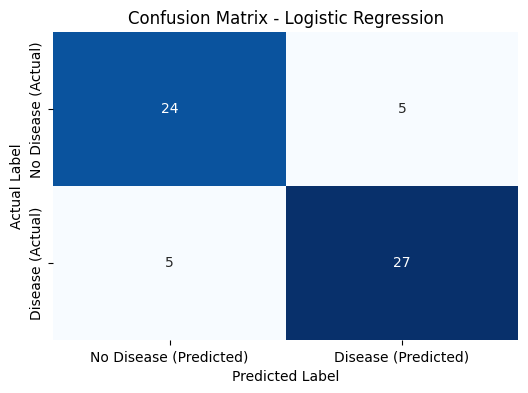

Confusion Matrix for Logistic Regression displayed successfully.


In [ ]:
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease (Predicted)', 'Disease (Predicted)'],
            yticklabels=['No Disease (Actual)', 'Disease (Actual)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
print("Confusion Matrix for Logistic Regression displayed successfully.")

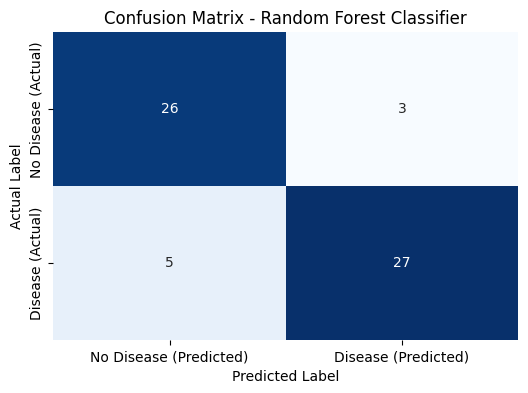

Confusion Matrix for Random Forest Classifier displayed successfully.


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease (Predicted)', 'Disease (Predicted)'],
            yticklabels=['No Disease (Actual)', 'Disease (Actual)'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
print("Confusion Matrix for Random Forest Classifier displayed successfully.")

**Perbandingan Kinerja Model dan Pentingnya Recall**
----------------------------------------------------

### **Evaluasi Model Logistic Regression**

*   **Accuracy:** 0,8361
    
*   **Precision:** 0,8438
    
*   **Recall:** 0,8438
    
*   **F1-Score:** 0,8438
    

### **Evaluasi Model Random Forest Classifier**

*   **Accuracy:** 0,8689
    
*   **Precision:** 0,9000
    
*   **Recall:** 0,8438
    
*   **F1-Score:** 0,8710
    

### **Perbandingan Kinerja Model**

Model **Random Forest Classifier** secara umum menunjukkan kinerja yang lebih baik dibandingkan **Logistic Regression**, terutama dari sisi **Accuracy, Precision, dan F1-Score**. Nilai akurasi yang lebih tinggi (0,8689 dibandingkan 0,8361) menunjukkan bahwa Random Forest melakukan lebih sedikit kesalahan prediksi secara keseluruhan. Selain itu, nilai precision yang lebih tinggi (0,9000 dibandingkan 0,8438) mengindikasikan bahwa Random Forest memiliki tingkat _false positive_ yang lebih rendah.

Menariknya, kedua model memiliki nilai **Recall yang sama**, yaitu **0,8438**.

### **Pentingnya Recall dalam Konteks Medis (Prediksi Penyakit Jantung)**

Dalam diagnosis medis, khususnya untuk penyakit serius seperti penyakit jantung, **Recall (Sensitivity)** merupakan metrik yang sangat krusial. Hal ini disebabkan oleh beberapa alasan utama:

*   **Meminimalkan** _**False Negative**_**:** Recall mengukur proporsi kasus positif aktual yang berhasil diidentifikasi dengan benar oleh model. Nilai recall yang tinggi berarti model mampu mendeteksi sebagian besar pasien yang benar-benar menderita penyakit jantung. Dalam konteks medis, kesalahan _false negative_ (pasien menderita penyakit jantung tetapi diprediksi tidak sakit) dapat berakibat fatal, karena dapat menyebabkan keterlambatan penanganan, perburukan kondisi, hingga risiko kematian. Sebaliknya, _false positive_ (pasien sehat yang diprediksi sakit) umumnya masih dapat ditoleransi karena hanya akan mengarah pada pemeriksaan lanjutan.
    
*   **Keamanan Pasien dan Intervensi Dini:** Deteksi dini sangat penting dalam penanganan penyakit jantung. Model dengan recall tinggi memastikan bahwa sangat sedikit kasus penyakit jantung yang terlewatkan, sehingga tenaga medis dapat melakukan intervensi lebih cepat. Meskipun _false positive_ dapat menimbulkan kecemasan dan pemeriksaan tambahan, risiko tersebut jauh lebih kecil dibandingkan dengan risiko akibat diagnosis yang terlewat.
    
*   **Keseimbangan Antar Metrik Evaluasi:** Meskipun recall menjadi prioritas utama, metrik lain seperti precision dan accuracy tetap penting. Model dengan recall sangat tinggi tetapi precision yang sangat rendah akan menghasilkan terlalu banyak alarm palsu, sehingga kurang berguna dalam praktik. Oleh karena itu, diperlukan keseimbangan antara metrik-metrik tersebut. Namun, pada kasus penyakit yang mengancam nyawa, penekanan lebih besar umumnya diberikan pada pencapaian recall yang tinggi, meskipun harus mengorbankan sedikit precision.
    

### **Kesimpulan**

Berdasarkan hasil evaluasi, **Random Forest Classifier** dapat dianggap sebagai model dengan kinerja keseluruhan yang sedikit lebih baik karena memiliki nilai accuracy, precision, dan F1-score yang lebih tinggi. Namun, nilai recall yang identik pada kedua model menunjukkan bahwa keduanya sama-sama efektif dalam mengidentifikasi pasien yang benar-benar menderita penyakit jantung pada data uji ini.

Untuk aplikasi kritis seperti prediksi penyakit jantung, **recall yang tinggi harus menjadi prioritas utama**. Oleh karena itu, pengembangan lebih lanjut seperti _threshold tuning_, penyesuaian bobot kelas, atau penggunaan model yang lebih canggih dapat dipertimbangkan guna meningkatkan recall tanpa menurunkan precision secara signifikan.

## Final Task

### Subtask:
Sajikan ringkasan hasil keseluruhan proyek, interpretasi temuan utama, sebutkan keterbatasan model atau data, dan berikan saran untuk pengembangan atau penelitian lebih lanjut.


## Summary:

### Q&A

**1\. Temuan Utama Proyek**
---------------------------

Proyek ini berhasil mengembangkan dan mengevaluasi dua model _machine learning_, yaitu **Logistic Regression** dan **Random Forest**, untuk memprediksi penyakit jantung. Proses pemahaman data menunjukkan bahwa dataset terdiri dari **303 entri**, dengan nilai hilang awal pada fitur **ca** dan **thal** yang kemudian ditangani menggunakan metode imputasi _modus_.

Analisis _Exploratory Data Analysis_ (EDA) menunjukkan bahwa variabel target bersifat **tidak seimbang**, dengan jumlah individu sehat lebih banyak dibandingkan individu yang menderita penyakit jantung. Selain itu, EDA juga mengidentifikasi fitur-fitur utama yang berkorelasi dengan penyakit jantung, di mana cp, exang, oldpeak, ca, dan thal menunjukkan korelasi positif, sedangkan thalach menunjukkan korelasi negatif.

Setelah dilakukan tahap _preprocessing_ (binarisasi target, _one-hot encoding_ untuk fitur kategorikal, dan _scaling_ untuk fitur numerik), kedua model dilatih dan dievaluasi. Hasil evaluasi menunjukkan bahwa **Random Forest** secara umum memiliki performa lebih baik dibandingkan **Logistic Regression** dalam hal **Accuracy, Precision, dan F1-Score**, meskipun kedua model memiliki nilai **Recall yang sama**.

**2\. Interpretasi Utama dari Temuan**
--------------------------------------

Hasil analisis menunjukkan bahwa faktor-faktor seperti **jenis nyeri dada**, **angina akibat aktivitas fisik**, **depresi segmen ST**, **jumlah pembuluh darah utama**, dan **hasil uji stres thallium** merupakan indikator kuat terjadinya penyakit jantung. Sebaliknya, **denyut jantung maksimum yang lebih tinggi** berkaitan dengan kemungkinan penyakit jantung yang lebih rendah.

Ketidakseimbangan pada variabel target menegaskan pentingnya evaluasi model secara hati-hati, khususnya dengan menekankan metrik **Recall**. Kinerja Random Forest yang lebih unggul secara keseluruhan, sambil mempertahankan nilai recall yang sama dengan Logistic Regression, menunjukkan bahwa Random Forest merupakan prediktor yang sedikit lebih baik untuk kasus ini.

**3\. Keterbatasan Model dan Data**
-----------------------------------

Beberapa keterbatasan yang teridentifikasi dalam proyek ini antara lain:

*   **Ketidakseimbangan Data:** Dataset didominasi oleh kasus tanpa penyakit jantung, sementara kasus dengan tingkat keparahan tinggi relatif lebih sedikit. Kondisi ini dapat menyebabkan model lebih fokus pada kelas mayoritas dan kurang optimal dalam memprediksi kelas minoritas.
    
*   **Ukuran Dataset:** Dengan hanya 303 entri, dataset tergolong kecil, sehingga dapat membatasi kemampuan generalisasi model, terutama untuk model yang lebih kompleks, serta meningkatkan variabilitas metrik evaluasi.
    
*   **Kompleksitas Fitur:** Fitur seperti ca dan thal pada awalnya bersifat kategorikal, namun setelah imputasi menggunakan modus diperlakukan sebagai numerik. Meskipun dalam tahap _preprocessing_ fitur-fitur ini telah dimasukkan ke dalam proses _one-hot encoding_ (yang merupakan langkah tepat), keterbatasan representasi tetap perlu diperhatikan.
    
*   **Keterbatasan Model:** Random Forest, meskipun kuat dan stabil, memiliki tingkat interpretabilitas yang lebih rendah dibandingkan Logistic Regression. Selain itu, kedua model dilatih tanpa proses _hyperparameter tuning_ yang mendalam, sehingga masih terdapat potensi peningkatan performa.
    

**4\. Saran untuk Pengembangan dan Penelitian Selanjutnya**
-----------------------------------------------------------

Beberapa arah pengembangan yang dapat dilakukan pada penelitian selanjutnya antara lain:

*   **Menangani Ketidakseimbangan Data:** Menerapkan teknik seperti _oversampling_ (misalnya SMOTE) atau _undersampling_ untuk menyeimbangkan dataset, sehingga model dapat lebih baik dalam mendeteksi kasus penyakit jantung yang jarang.
    
*   **Hyperparameter Tuning:** Melakukan optimasi parameter model, khususnya pada Random Forest, menggunakan metode seperti _GridSearchCV_ atau _RandomizedSearchCV_ untuk meningkatkan performa prediksi.
    
*   **Optimasi Threshold Klasifikasi:** Mengeksplorasi penyesuaian ambang batas (_decision threshold_) untuk lebih memprioritaskan Recall, mengingat pentingnya meminimalkan _false negative_ dalam diagnosis medis.
    
*   **Feature Engineering dan Seleksi Fitur:** Mengembangkan fitur baru dari fitur yang sudah ada serta menerapkan teknik seleksi fitur lanjutan guna mengidentifikasi prediktor yang paling berpengaruh.
    
*   **Validasi Eksternal:** Menguji model terbaik pada dataset independen yang belum pernah dilihat sebelumnya untuk menilai kemampuan generalisasi dan keandalannya dalam kondisi dunia nyata.
    

**Ringkasan Temuan Analisis Data**
----------------------------------

*   Dataset terdiri dari **303 data pasien** dengan **14 fitur**, dengan nilai hilang pada ca dan thal yang diimputasi menggunakan modus.
    
*   Variabel target bersifat **imbalanced**, dengan **164 kasus tanpa penyakit** dan **139 kasus dengan penyakit** setelah binarisasi.
    
*   Fitur dengan korelasi positif terhadap penyakit jantung: cp, exang, oldpeak, ca, dan thal.
    
*   Fitur thalach menunjukkan korelasi negatif terhadap penyakit jantung.
    
*   Data dibagi menjadi **242 data latih** dan **61 data uji** setelah _preprocessing_.
    
*   **Random Forest** menunjukkan performa keseluruhan yang sedikit lebih baik dibandingkan **Logistic Regression**, dengan nilai recall yang sama pada kedua model.
    

**Insight dan Langkah Selanjutnya**
-----------------------------------

Dalam konteks medis, **Recall harus menjadi prioritas utama** untuk meminimalkan risiko kasus penyakit jantung yang tidak terdeteksi. Oleh karena itu, penelitian lanjutan sebaiknya berfokus pada peningkatan recall melalui penyesuaian threshold, optimasi model, dan penanganan ketidakseimbangan data. Selain itu, eksplorasi metode _ensemble_ yang lebih canggih atau model berbasis _neural network_ dapat dipertimbangkan untuk meningkatkan kekuatan prediksi dan ketahanan model.